# ML Superset: Smarter Bank Campaigns

## Task 1 — Supervised Learning: Who is likely to subscribe?

### Objective

The objective is to use historical bank marketing contact records to predict
which clients are more likely to subscribe to a term deposit.

The bank has capacity to make only 500 calls. Therefore, the model will
eventually produce a ranked subscription score so that records can be
prioritised.

The prediction must use information that would be available before the
call starts.

This is a predictive analysis rather than a causal analysis. Historical
data can identify records associated with subscription, but it cannot prove
that contacting a client causes the subscription.


In [ ]:
import pandas as pd
import numpy as np

# Load the full UCI Bank Marketing dataset.
# sep=";" is required because the CSV uses semicolons as separators.
df = pd.read_csv("bank-additional-full.csv", sep=";")


### Dataset shape

The dataset contains 41,188 historical contact records and 21 columns.
There are 20 input variables and one binary target variable, `y`.

The full `bank-additional-full.csv` file is used rather than the smaller
4,119-record sample, as required by the assignment.


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)


Number of rows: 41188
Number of columns: 21
Dataset shape: (41188, 21)


In [ ]:
print(df.head())
print(df.tail())
print(df.info())
print(df.describe())

In [ ]:
print(df.columns.tolist())


In [ ]:
# Create a basic variable summary

variable_summary = pd.DataFrame({
    "Variable": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isna().sum()
})

variable_summary


NameError: name 'df' is not defined

In [ ]:
# Count missing values in every column

missing_values = df.isna().sum()

print(missing_values)


NameError: name 'df' is not defined

In [ ]:
# Missing-value summary

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary

# Total number of missing cells

print("Total missing cells:", df.isna().sum().sum())


In [ ]:
# Identify numerical variables

numeric_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical variables

categorical_cols = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


In [ ]:
target_counts = df["y"].value_counts()
print(target_counts)

target_percentages = (
    df["y"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(target_percentages)

target_summary = pd.DataFrame({
    "Count" : target_counts,
    "Percentage" : target_percentages
})

print(target_summary)

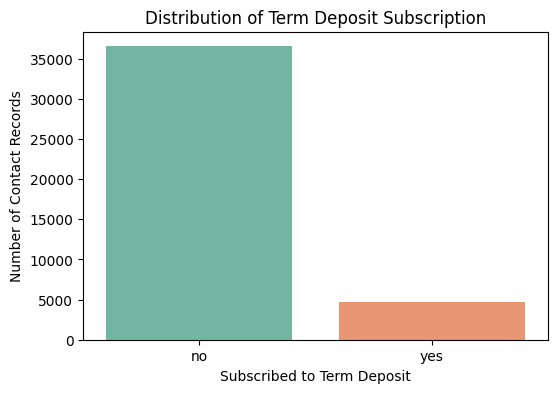

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create a figure that is 6 inches wide and 4 inches tall
plt.figure(figsize=(6, 4))

# Create a bar chart showing the number of records for each target class
sns.countplot(
    data=df,              # Use our dataset
    x="y",                # Put the target variable on the x-axis
    hue="y",              # Use target categories to colour the bars
    palette="Set2",       # Choose a colour palette
    legend=False          # No separate legend is needed
)

# Add a descriptive title
plt.title("Distribution of Term Deposit Subscription")

# Label the x-axis
plt.xlabel("Subscribed to Term Deposit")

# Label the y-axis
plt.ylabel("Number of Contact Records")

# Display the completed plot
plt.show()


In [ ]:
# Create an empty dictionary to store unknown-value counts
unknown_counts = {}

# Check every column in the dataset
for column in df.columns:

    # Convert values to lowercase text and check which ones are "unknown"
    # .sum() counts how many True values were found
    unknown_counts[column] = (
        df[column].astype(str).str.lower() == "unknown"
    ).sum()

# Convert the dictionary into a Pandas Series
unknown_counts = pd.Series(unknown_counts)

# Create a table containing the count and percentage of unknown values
unknown_summary = pd.DataFrame({
    "Unknown Count": unknown_counts,

    # Calculate what percentage of the dataset is unknown
    "Unknown Percentage": (
        unknown_counts / len(df) * 100
    ).round(2)
})

# Show only columns that actually contain unknown values
# Sort them from the most unknown values to the least
unknown_summary[
    unknown_summary["Unknown Count"] > 0
].sort_values(
    "Unknown Count",
    ascending=False
)


In [ ]:
# Show how many times each pdays value appears
# sort_index() displays the values from smallest to largest
print(df["pdays"].value_counts().sort_index())


In [ ]:
# Examine how often each value of pdays appears
# sort_index() arranges the pdays values from smallest to largest
print(df["pdays"].value_counts().sort_index())


# Count the number of records where pdays is equal to 999
# 999 is a special code in this dataset
pdays_999_count = (df["pdays"] == 999).sum()


# Calculate what percentage of all records have pdays = 999
pdays_999_percentage = (
    pdays_999_count / len(df) * 100
)


# Display the number of records with pdays = 999
print(
    "Number of contact records with pdays = 999:",
    pdays_999_count
)


# Display the percentage of records with pdays = 999
# round(..., 2) keeps the result to 2 decimal places
print(
    "Percentage of contact records with pdays = 999:",
    round(pdays_999_percentage, 2),
    "%"
)


# Create a temporary binary indicator:
# 1 = pdays is 999
# 0 = pdays is not 999
pdays_999 = (df["pdays"] == 999).astype(int)


# Count how many records have pdays = 999 and how many do not
print(
    pdays_999.value_counts()
)


In [ ]:
# Descriptive statistics for numerical variables
# Shows count, mean, standard deviation, quartiles and range
# Transpose makes each numerical variable appear as a row
df[numeric_cols].describe().T


In [ ]:
# Display the categories and their frequencies for each categorical variable

for column in categorical_cols:

    # Print a separator to make the output easier to read
    print("\n" + "=" * 60)

    # Display the name of the current column
    print(column)

    # Print another separator
    print("=" * 60)

    # Count each category
    # dropna=False also shows NaN values if they exist
    print(df[column].value_counts(dropna=False))


job
student          31.43
retired          25.23
unemployed       14.20
admin.           12.97
management       11.22
unknown          11.21
technician       10.83
self-employed    10.49
housemaid        10.00
entrepreneur      8.52
services          8.14
blue-collar       6.89
Name: y, dtype: float64


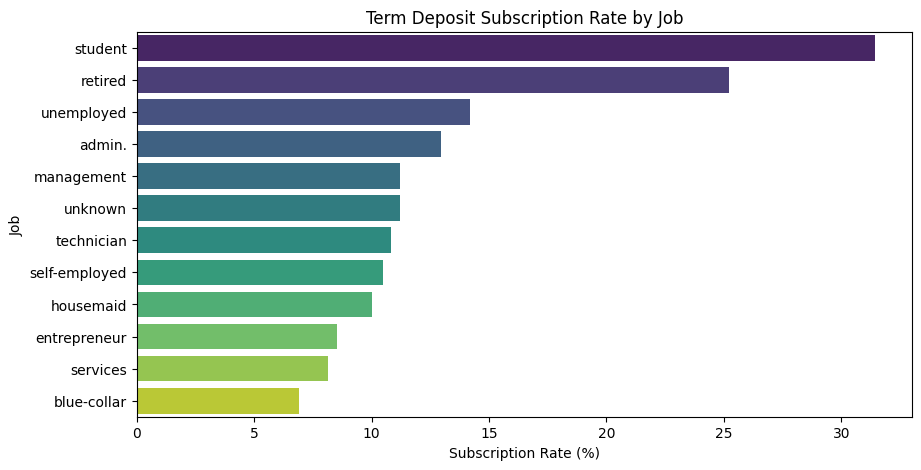

In [ ]:
# Calculate subscription rate by job

job_subscription = (
    df.groupby("job")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(job_subscription.round(2))

plt.figure(figsize=(10, 5))

sns.barplot(
    x=job_subscription.values,
    y=job_subscription.index,
    hue=job_subscription.index,
    palette="viridis",
    legend=False
)

plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.title("Term Deposit Subscription Rate by Job")

plt.show()



contact
cellular     14.74
telephone     5.23
Name: y, dtype: float64


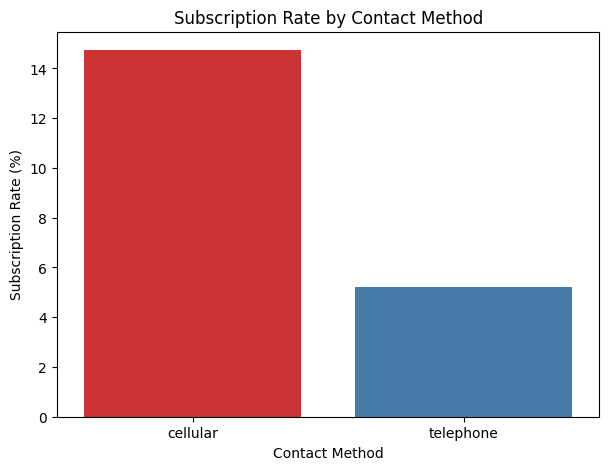

In [ ]:
# Subscription rate by contact method

contact_subscription = (
    df.groupby("contact")["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(contact_subscription.round(2))

plt.figure(figsize=(7, 5))

sns.barplot(
    x=contact_subscription.index,
    y=contact_subscription.values,
    hue=contact_subscription.index,
    palette="Set1",
    legend=False
)

plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate (%)")
plt.title("Subscription Rate by Contact Method")

plt.show()


In [ ]:
# Relationship: Previous campaign outcome (poutcome) vs subscription (y)

# Group customers according to their previous campaign outcome,
# then calculate the proportion of "yes" and "no" subscriptions
# within each poutcome group.
poutcome_subscription = (
    df.groupby("poutcome")["y"]
      .value_counts(normalize=True)
      .unstack()
      .fillna(0)
)

# Select the "yes" subscription column and convert the proportions
# into percentages by multiplying them by 100.
poutcome_subscription["yes"] = (
    poutcome_subscription["yes"] * 100
)

# Display the subscription rate for each previous campaign outcome.
poutcome_subscription[["yes"]]

y,yes
poutcome,
failure,14.228598
nonexistent,8.832213
success,65.112891


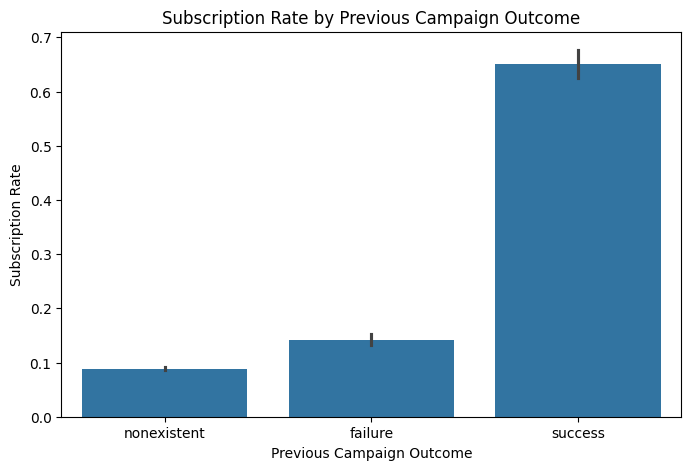

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="poutcome",
    y=df["y"].eq("yes").astype(int)
)

plt.ylabel("Subscription Rate")
plt.xlabel("Previous Campaign Outcome")
plt.title("Subscription Rate by Previous Campaign Outcome")
plt.show()


In [ ]:
# Relationship: Number of campaign contacts (campaign) vs subscription (y)

# Define groups for the number of contacts made during the campaign.
# Grouping the values makes the relationship easier to interpret
# than plotting every individual campaign value.
campaign_bins = [0, 1, 2, 3, 5, 10, float("inf")]

# Define readable labels for the contact groups.
campaign_labels = [
    "1",
    "2",
    "3",
    "4–5",
    "6–10",
    "11+"
]

# Create a temporary column that assigns each customer
# to one of the campaign contact groups.
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=campaign_bins,
    labels=campaign_labels
)

# Calculate the subscription rate within each campaign group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.
campaign_subscription = (
    df.groupby("campaign_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each campaign contact group.
campaign_subscription

,campaign_group,subscription_rate
0,1,13.037071
1,2,11.456954
2,3,10.747051
3,4–5,8.682353
4,6–10,6.319555
5,11+,3.107020


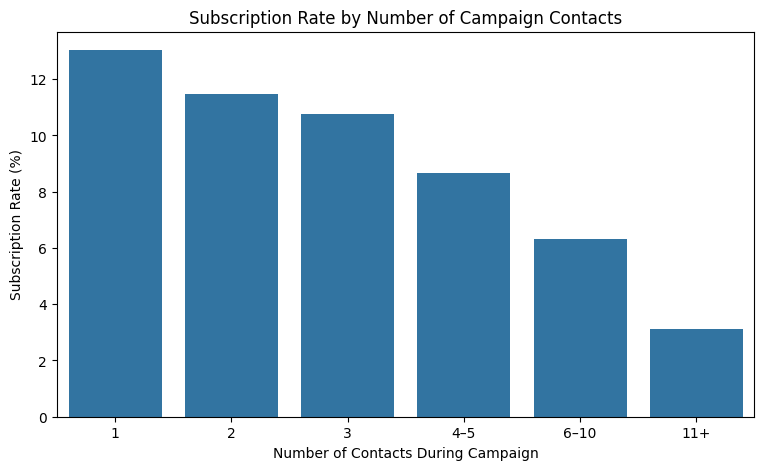

In [ ]:
# Plot the subscription rate for each campaign contact group.

plt.figure(figsize=(9, 5))

# Create a bar chart showing the subscription rate
# for each number-of-contact group.
sns.barplot(
    data=campaign_subscription,
    x="campaign_group",
    y="subscription_rate"
)

# Label the x-axis to explain what the groups represent.
plt.xlabel("Number of Contacts During Campaign")

# Label the y-axis to show that the values are percentages.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title to the chart.
plt.title("Subscription Rate by Number of Campaign Contacts")

# Display the chart.
plt.show()

In [ ]:
# Define groups for the number of days since the client was previously contacted.
# The value 999 is treated separately because it represents clients
# who were not previously contacted in the relevant campaign history.

pdays_bins = [-1, 7, 30, 90, float("inf")]

# Define readable labels for the pdays groups.
pdays_labels = [
    "0–7",
    "8–30",
    "31–90",
    "91+"
]

# Create a temporary column that groups pdays values.
# Values equal to 999 will be handled separately below.
df["pdays_group"] = pd.cut(
    df["pdays"].where(df["pdays"] != 999),
    bins=pdays_bins,
    labels=pdays_labels
)

In [ ]:
# Convert the categorical column to an ordinary object column.
# This allows us to add our special 999 category.
df["pdays_group"] = df["pdays_group"].astype(object)

# Assign a separate label to customers with pdays = 999.
df.loc[
    df["pdays"] == 999,
    "pdays_group"
] = "999 (not previously contacted)"

df[["pdays", "pdays_group"]].head(10)

,pdays,pdays_group
0,999,999 (not previously contacted)
1,999,999 (not previously contacted)
2,999,999 (not previously contacted)
3,999,999 (not previously contacted)
4,999,999 (not previously contacted)
5,999,999 (not previously contacted)
6,999,999 (not previously contacted)
7,999,999 (not previously contacted)
8,999,999 (not previously contacted)
9,999,999 (not previously contacted)


In [ ]:
# Calculate the subscription rate within each pdays group.
# (y == "yes") identifies customers who subscribed.
# The mean of these True/False values gives the proportion
# of customers who subscribed, which is then multiplied by 100
# to express the result as a percentage.

pdays_subscription = (
    df.groupby("pdays_group", observed=False)["y"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .reset_index(name="subscription_rate")
)

# Display the subscription rate for each pdays group.
pdays_subscription

,pdays_group,subscription_rate
0,0–7,65.760408
1,8–30,57.100592
2,999 (not previously contacted),9.258186


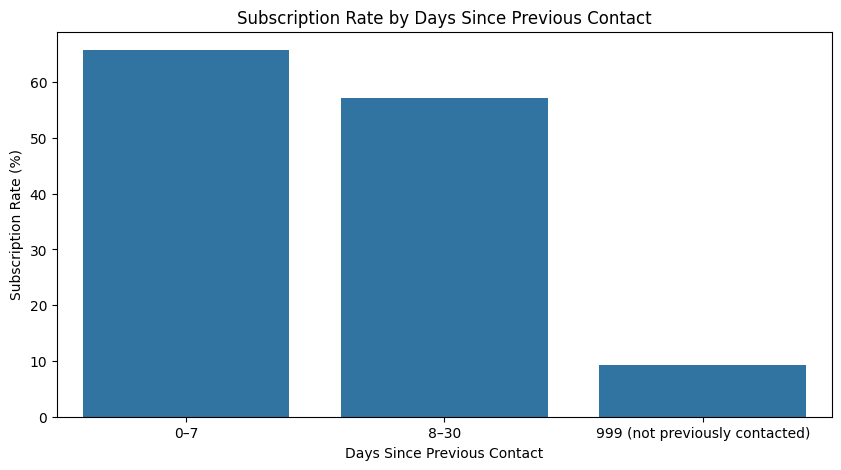

In [ ]:
# Plot the subscription rate for each pdays group.

plt.figure(figsize=(10, 5))

# Create a bar chart using the pdays groups on the x-axis
# and their subscription rates on the y-axis.
sns.barplot(
    data=pdays_subscription,
    x="pdays_group",
    y="subscription_rate"
)

# Label the x-axis.
plt.xlabel("Days Since Previous Contact")

# Label the y-axis.
plt.ylabel("Subscription Rate (%)")

# Add a descriptive title.
plt.title("Subscription Rate by Days Since Previous Contact")

# Display the chart.
plt.show()

## Feature availability table

| Input column     | Type        | Available before call? | Include? | Reason                                                                                                                             |
| ---------------- | ----------- | ---------------------: | -------: | ---------------------------------------------------------------------------------------------------------------------------------- |
| `age`            | Numeric     |                  ✅ Yes |        ✅ | Customer's age is already known from customer records.                                                                             |
| `job`            | Categorical |                  ✅ Yes |        ✅ | Occupation information is available from customer records.                                                                         |
| `marital`        | Categorical |                  ✅ Yes |        ✅ | Marital status is existing customer information.                                                                                   |
| `education`      | Categorical |                  ✅ Yes |        ✅ | Education information is available before the campaign call.                                                                       |
| `default`        | Categorical |                  ✅ Yes |        ✅ | Existing information about credit in default can be known before calling.                                                          |
| `housing`        | Categorical |                  ✅ Yes |        ✅ | Housing-loan status is pre-existing customer information.                                                                          |
| `loan`           | Categorical |                  ✅ Yes |        ✅ | Personal-loan status is available before the call.                                                                                 |
| `contact`        | Categorical |                  ✅ Yes |        ✅ | The contact method/type is part of the campaign setup and can be known before the call.                                            |
| `month`          | Categorical |                  ✅ Yes |        ✅ | Campaign month is known when planning the campaign.                                                                                |
| `day_of_week`    | Categorical |                  ✅ Yes |        ✅ | Planned day of contact is known before the call.                                                                                   |
| `duration`       | Numeric     |                   ❌ No |        ❌ | Call duration is only known during/after the call, so it cannot be used to decide whom to call.                                    |
| `campaign`       | Numeric     |                 ✅ Yes* |        ✅ | Number of contacts already made during the campaign can be used under our operational decision-point interpretation.               |
| `pdays`          | Numeric     |                  ✅ Yes |        ✅ | Previous-contact history is known before a new call.                                                                               |
| `previous`       | Numeric     |                  ✅ Yes |        ✅ | Number of contacts in previous campaigns is historical information.                                                                |
| `poutcome`       | Categorical |                  ✅ Yes |        ✅ | Outcome of the previous campaign is historical information available before the current call.                                      |
| `emp.var.rate`   | Numeric     |                  ✅ Yes |        ✅ | Employment-variation rate is a macroeconomic indicator associated with the campaign period and is known externally before contact. |
| `cons.price.idx` | Numeric     |                  ✅ Yes |        ✅ | Consumer price index is a macroeconomic indicator available for the campaign period.                                               |
| `cons.conf.idx`  | Numeric     |                  ✅ Yes |        ✅ | Consumer confidence index is an external economic indicator available for the campaign period.                                     |
| `euribor3m`      | Numeric     |                  ✅ Yes |        ✅ | Euribor 3-month rate is an external economic indicator available for the campaign period.                                          |
| `nr.employed`    | Numeric     |                  ✅ Yes |        ✅ | Number of employees/economic employment indicator is available for the campaign period.                                            |


In [ ]:
# Define the original input features that are available before the call.
# These are the 19 features we decided to keep for modelling.
feature_columns = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

# Create the modelling feature matrix using only the original input columns.
# This prevents exploratory columns such as campaign_group and pdays_group
# from accidentally being used as model features.
X = df[feature_columns].copy()

# Keep the target variable separate from the input features.
y = df["y"].copy()

# Check the number and names of modelling features.
print("Number of modelling features:", X.shape[1])
print("\nModelling features:")
print(X.columns.tolist())




Number of modelling features: 19

Modelling features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [ ]:
# Automatically identify numerical features in X
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Automatically identify categorical features in X
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display the feature groups
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("Total number of Numerical Features : ",len(numeric_features))
print("Total number of Categorical Features : ",len(categorical_features))


Numerical features:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Total number of Numerical Features :  9
Total number of Categorical Features :  10


## Handling of `unknown` Values

The dataset contains the value `unknown` in some categorical variables. These values are treated as an explicit category rather than being automatically converted into missing values.

Keeping `unknown` as a separate category preserves the information that the value was not available or was recorded as unknown in the original dataset.

Therefore, the preprocessing pipeline will not replace `unknown` with the most frequent category. Instead, `unknown` will remain as a categorical level and will be handled by one-hot encoding.

Actual missing values (`NaN`), if present, will be handled separately by the preprocessing pipeline:
- numerical variables: median imputation
- categorical variables: most-frequent imputation

In [ ]:
# Import tools for numerical preprocessing
# Import the standard Pipeline class
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Create a preprocessing pipeline for numerical features
numeric_transformer = Pipeline(
    steps=[
        (
            # Fill missing numerical values with the median
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            # Scale numerical features to a similar range
            "scaler",
            StandardScaler()
        )
    ]
)

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        (
            # Fill missing categorical values with the most common category
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            # Convert categories into numerical 0/1 columns
            # Ignore categories that appear only in new data
            "encoder",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)


In [ ]:
# Import ColumnTransformer
from sklearn.compose import ColumnTransformer

# Apply the appropriate preprocessing to each type of feature
preprocessor = ColumnTransformer(
    transformers=[
        (
            # Numerical preprocessing
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            # Categorical preprocessing
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


In [ ]:

preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor)
    ]
)

print(preprocessing_pipeline)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                      

In [ ]:
# Create a time-ordered train/holdout split.
# The earlier 80% is used for model development.
# The later 20% is reserved as the final holdout.

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index].copy()
X_holdout = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_holdout = y.iloc[split_index:].copy()

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nFinal holdout data:")
print("X_holdout:", X_holdout.shape)
print("y_holdout:", y_holdout.shape)

Training data:
X_train: (32950, 19)
y_train: (32950,)

Final holdout data:
X_holdout: (8238, 19)
y_holdout: (8238,)


In [ ]:
# Fit the preprocessing pipeline using training data only.
# This learns the median values, most-frequent categories,
# scaling parameters, and categorical encoding from X_train only.

X_train_transformed = preprocessing_pipeline.fit_transform(X_train)

# Apply the already-fitted preprocessing pipeline to the final holdout.
# No fitting is performed on the holdout.

X_holdout_transformed = preprocessing_pipeline.transform(X_holdout)

print("Transformed training shape:", X_train_transformed.shape)
print("Transformed holdout shape:", X_holdout_transformed.shape)

Transformed training shape: (32950, 61)
Transformed holdout shape: (8238, 61)


In [ ]:
# Check that the preprocessing produced the expected number of features.
print("\nOriginal training features:", X_train.shape[1])
print("Transformed training features:", X_train_transformed.shape[1])

# Check that the training and holdout data have the same transformed structure.
print("Transformed training rows:", X_train_transformed.shape[0])
print("Transformed holdout rows:", X_holdout_transformed.shape[0])


Original training features: 19
Transformed training features: 61
Transformed training rows: 32950
Transformed holdout rows: 8238
